In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
datasets = Path("datasets").glob("*.csv")
file_path = []
for file in datasets:
    file_path.append(file)

df_list = []
for file in file_path:
    df_list.append(pd.read_csv(file, index_col=0))
for df in df_list:     print(df.shape)

(18429, 25)
(19749, 25)
(3921, 25)
(32848, 25)
(30737, 25)
(21021, 25)
(16973, 25)
(34698, 25)
(15803, 25)
(34245, 25)


In [2]:
df = df_list[0].dropna()
df.head()

,L_1,L_2,A_1,A_2,B_1,B_2,C_1,C_2,A_3,A_4,...,L_4,L_5,L_6,L_7,L_8,L_9,L_10,A_5,B_5,C_5
Timestamp,,,,,,,,,,,,,,,,,,,,,
0,-20.470767,-49.583696,-49.737023,-60.125877,-67.684702,-67.213115,-75.635206,-75.398126,-45.568737,-59.348954,...,-98.610796,-77.922564,-65.288020,-21.577296,-5.229818,-20.021259,-53.399733,-100.0,-100.0,-100.0
1,-4.874715,-37.094569,-25.009528,-35.579886,-33.459741,-35.514754,-33.369469,-35.644538,-51.259983,-62.808618,...,-98.610796,-77.922564,-59.527626,-8.114661,-7.114716,-4.532685,-52.568426,-100.0,-100.0,-100.0
2,25.132878,-40.673543,-25.040018,-35.461876,-33.527460,-35.659016,-33.274612,-35.644538,-56.656587,-66.582796,...,-98.610796,-77.922564,-67.083467,22.033657,-17.198404,25.123377,-47.439417,-100.0,-100.0,-100.0
3,-90.508732,-76.363862,-25.238204,-35.592998,-33.459741,-35.593443,-33.396572,-35.552789,-52.903776,-61.912250,...,-98.610796,-77.922564,-98.546543,-85.325157,-41.011974,-91.739428,-93.192691,-100.0,-100.0,-100.0
4,-95.641610,-62.582329,-24.963793,-35.488101,-33.459741,-35.449180,-33.369469,-35.552789,-56.377452,-64.239660,...,-98.610796,-77.922564,-82.718820,-92.213349,-24.248745,-96.082302,-70.919928,-100.0,-100.0,-100.0


In [3]:
column = df.columns
pearson_score_dict = {}
for i in range(len(column)):
    for j in range(i+1, len(column)):
        column1 = column[i]
        column2 = column[j]
        pearson_corr = df[column1].corr(df[column2], method='pearson')
        pearson_score_dict[(column1, column2)] = pearson_corr
    
#sort by pearson correlation score in descending order
pearson_score_list = sorted(pearson_score_dict.items(), key=lambda x: abs(x[1]), reverse=True)
# print the top comparisons
i = 1
for comparison in pearson_score_list[:10]:
        print(i, " ", comparison)
        i += 1
        

1   (('L_7', 'L_9'), np.float64(0.9997683255494698))
2   (('L_1', 'L_9'), np.float64(0.9992596898295507))
3   (('L_1', 'L_7'), np.float64(0.998981871895985))
4   (('A_2', 'B_2'), np.float64(0.9907576327813764))
5   (('B_2', 'C_2'), np.float64(0.9838853922346588))
6   (('B_2', 'B_4'), np.float64(0.9826012945396012))
7   (('A_5', 'C_5'), np.float64(0.9798451020246295))
8   (('A_2', 'A_4'), np.float64(0.9796261208680205))
9   (('C_2', 'C_4'), np.float64(0.9794591675593762))
10   (('A_1', 'A_3'), np.float64(0.9783105807831834))


In [4]:
column = df.columns
spearman_score_dict = {}
for i in range(len(column)):
    for j in range(i+1, len(column)):
        column1 = column[i]
        column2 = column[j]
        spearman_corr = df[column1].corr(df[column2], method='spearman')
        spearman_score_dict[(column1, column2)] = spearman_corr
    
#sort by spearman correlation score in descending order
spearman_score_list = sorted(spearman_score_dict.items(), key=lambda x: abs(x[1]), reverse=True)
# print the top comparisons and add the lower ones to spearman list
i = 1
for comparison in spearman_score_list[:10]:
    print(i, " ", comparison)
    i += 1

1   (('A_5', 'C_5'), np.float64(0.9994636792765011))
2   (('L_1', 'L_9'), np.float64(0.9973382089025498))
3   (('L_1', 'L_7'), np.float64(0.9942375529380241))
4   (('L_7', 'L_9'), np.float64(0.9936755451345508))
5   (('B_5', 'C_5'), np.float64(0.8912971027135747))
6   (('A_5', 'B_5'), np.float64(0.8911850978334575))
7   (('L_4', 'L_5'), np.float64(0.8799606506230822))
8   (('L_3', 'L_6'), np.float64(0.8518833145531431))
9   (('A_2', 'A_4'), np.float64(0.8394115383623548))
10   (('A_1', 'A_3'), np.float64(0.7944490394393648))


In [5]:
two_score_list = []
for key in pearson_score_dict.keys():
    weighted_score = abs(abs(pearson_score_dict[key]) - abs(spearman_score_dict[key]))+abs(spearman_score_dict[key])
    two_score_list.append((key, pearson_score_dict[key], spearman_score_dict[key], weighted_score))
two_score_list.sort(key=lambda x: abs(x[3]), reverse=True)
score_df = pd.DataFrame(two_score_list, columns=["Column Pair", "Pearson Score", "Spearman Score", "Weighted Score"])
score_df.head(10)

,Column Pair,Pearson Score,Spearman Score,Weighted Score
0,"(L_2, L_4)",0.511933,0.790837,1.069741
1,"(L_2, L_5)",0.470455,0.762122,1.053790
2,"(A_5, C_5)",0.979845,0.999464,1.019082
3,"(L_7, L_9)",0.999768,0.993676,0.999768
4,"(L_1, L_9)",0.999260,0.997338,0.999260
5,"(L_1, L_7)",0.998982,0.994238,0.998982
6,"(A_2, B_2)",0.990758,0.423724,0.990758
7,"(B_2, C_2)",0.983885,0.415096,0.983885
8,"(B_2, B_4)",0.982601,0.401531,0.982601
9,"(A_2, A_4)",0.979626,0.839412,0.979626


<Axes: title={'center': 'Pearson: 0.51, Spearman: 0.79, Weighted: 1.07'}, xlabel='L_2', ylabel='L_4'>

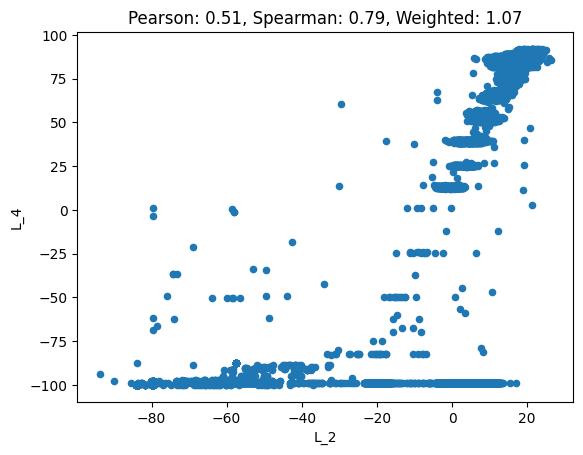

In [6]:
((column1, column2), pearson_score, spearman_score, weighted_score) = two_score_list[0]
df.plot.scatter(x=column1, y=column2, title=f"Pearson: {pearson_score:.2f}, Spearman: {spearman_score:.2f}, Weighted: {weighted_score:.2f}")

Rows kept: 8971
Rows removed (non-positive): 9458


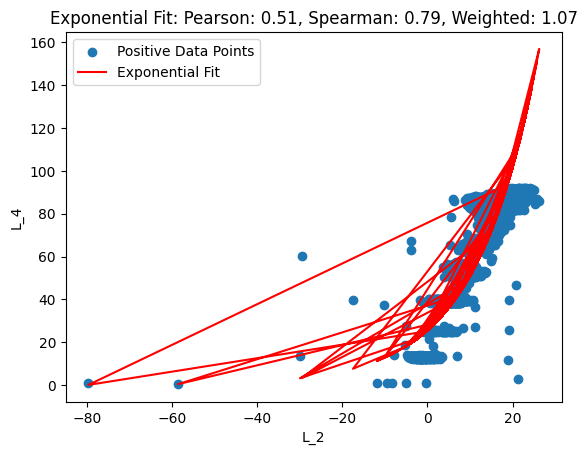

In [7]:
# linear regression of exponential data
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Filter to rows where the target column is strictly positive.
# log(y) is only defined for y > 0, so negative and zero values are excluded.
positive_mask = df[column2] > 0
filtered_df = df.loc[positive_mask].copy()

print(f"Rows kept: {len(filtered_df)}")
print(f"Rows removed (non-positive): {len(df) - len(filtered_df)}")

if len(filtered_df) < 2:
    raise ValueError(f"Not enough positive values in {column2} to fit an exponential model.")

ln_column2 = np.log(filtered_df[column2])
model = LinearRegression()
model.fit(filtered_df[[column1]], ln_column2)
predicted_ln_column2 = model.predict(filtered_df[[column1]])
predicted_column2 = np.exp(predicted_ln_column2)

plt.scatter(filtered_df[column1], filtered_df[column2], label='Positive Data Points')
plt.plot(filtered_df[column1], predicted_column2, color='red', label='Exponential Fit')
plt.xlabel(column1)
plt.ylabel(column2)
plt.title(f"Exponential Fit: Pearson: {pearson_score:.2f}, Spearman: {spearman_score:.2f}, Weighted: {weighted_score:.2f}")
plt.legend()
plt.show()